In [ ]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted
from scipy.spatial.distance import cdist

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier


from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder, LabelEncoder
from collections import Counter

import shap

from sklearn.cluster import KMeans
from kneed import KneeLocator
from scipy.spatial.distance import pdist, squareform

In [3]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [4]:
data_dir = Path('../results') 

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [5]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

In [6]:
# Define target variables

y_train_titleType = df_train['titleType']
y_test_titleType = df_test['titleType']

# Pre-processing (only for titleType)

In [7]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)

Train and test columns match.


In [8]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [9]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 25
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

In [10]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 25
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

In [11]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [12]:
# drop target variable and rating (we'll use averageRating)
df_train.drop(columns=['rating', 'titleType'], inplace=True) 
df_test.drop(columns=['rating', 'titleType'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions',
       'countryOfOrigin', 'genres', 'companiesNumber', 'averageRating',
       'regions', 'externalLinks', 'writerCredits', 'numGenres',
       'criticReviewsRatio', 'hasAwards', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [13]:
# overwrite to make sure they're up to date

num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [14]:
num_cols, bool_cols, cat_cols

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
        'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index([], dtype='object'))

In [15]:
# Preprocess Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [16]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        'Return feature names for output features'
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [17]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols), #TREES: NO SCALING NEEDED
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': RF handles redundant feats
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

# Load RF model for title type, SHAP

In [18]:
rf_pipeline = joblib.load(data_dir / 'RF_tts.pkl')

print(f"Model type: {type(rf_pipeline)}")
print(f"Model classes: {rf_pipeline.classes_}")

Model type: <class 'sklearn.pipeline.Pipeline'>
Model classes: ['movie' 'short' 'tvEpisode' 'tvMiniSeries' 'tvMovie' 'tvSeries' 'tvShort'
 'tvSpecial' 'video' 'videoGame']


In [19]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
rf_classifier = rf_pipeline.named_steps['clf']

In [20]:
# Get the preprocessed data
X_test = rf_pipeline.named_steps['preprocessor'].transform(df_test)

# K-Means
Since SHAP is computationally expensive, we'll only run it on prototypical instances on the test set. We'll cluster the dataset using K-Means and approximate the medoids by taking the datapoints closest to the centroids (problems installing K-Medoid). For simplicity, we'll only use numerical features. 

## Determining the best K

In [21]:
numerical_df = df_test[num_cols]
scaler = RobustScaler()
X = scaler.fit_transform(numerical_df.values)

In [22]:
%%time
sse_list = []

for k in range(2, 101): 
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    kmeans.fit(X)
    sse_list.append(kmeans.inertia_) #sse

CPU times: total: 26min 28s
Wall time: 7min 26s


In [24]:
k_values = list(range(2, 101))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 13


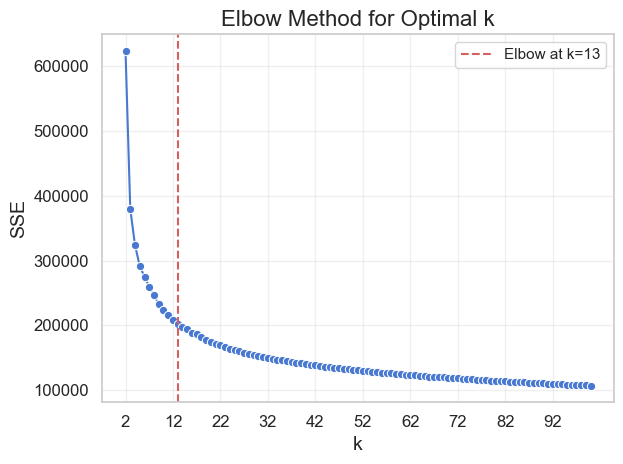

In [27]:
#plt.figure(figsize=(10, 6))
sns.lineplot(x=k_values, y=sse_list, marker='o')
plt.xlabel('k', fontsize=14)
plt.ylabel('SSE', fontsize=14)
plt.title('Elbow Method for Optimal k', fontsize=16)
if knee_locator.knee:
    plt.axvline(knee_locator.knee, color='r', linestyle='--', label=f'Elbow at k={knee_locator.knee}')
    plt.legend()
plt.xticks(np.arange(2, 101, 10), fontsize=12)  # Show every 10th tick from 2 to 100
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## k = 13

In [30]:
k = 13
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=0)
kmeans.fit(X)

,n_clusters,13
,init,'k-means++'
,n_init,10
,max_iter,100
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [31]:
labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', kmeans.inertia_)
print('Silhouette score:', silhouette_score(X, kmeans.labels_))

Cluster sizes:
Cluster 0:	3409
Cluster 1:	6269
Cluster 2:	2143
Cluster 3:	1715
Cluster 4:	2347
Cluster 5:	8372
Cluster 6:	8072
Cluster 7:	1124
Cluster 8:	2792
Cluster 9:	2804
Cluster 10:	3517
Cluster 11:	1358
Cluster 12:	935

SSE: 202118.2923306182
Silhouette score: 0.18183147658479276


## Find "medoids"
Find the points in my original dataset that correspond to the closest K-means centroids.

In [36]:
# Find the closest points to each centroid
def find_medoids(X_scaled, centroids, X_original, df_original):
    """
    Find the points closest to centroids (medoids) and return their info
    
    Parameters:
    - X_scaled: scaled numerical features used for clustering
    - centroids: cluster centroids from kmeans
    - X_original: original preprocessed data (X_test)
    - df_original: original dataframe (df_test)
    """
    medoid_indices = []
    medoid_info = []
    
    # Calculate distances from all points to all centroids
    distances = cdist(X_scaled, centroids, metric='euclidean') #cdist
    
    # For each cluster, find the closest point to its centroid
    for i in range(len(centroids)):
        closest_point_idx = np.argmin(distances[:, i])
        medoid_indices.append(closest_point_idx)
        
        # Store information about this medoid
        medoid_info.append({
            'cluster': i,
            'index': closest_point_idx,
            'distance_to_centroid': distances[closest_point_idx, i],
            'original_data_index': df_original.index[closest_point_idx]
        })
    
    return medoid_indices, medoid_info

In [37]:
medoid_indices, medoid_info = find_medoids(X, kmeans.cluster_centers_, X_test, df_test)

print("Medoid information:")
for info in medoid_info:
    print(f"Cluster {info['cluster']}: Index {info['index']} (original row {info['original_data_index']}), "
          f"Distance to centroid: {info['distance_to_centroid']:.4f}")

Medoid information:
Cluster 0: Index 20235 (original row 20235), Distance to centroid: 0.8444
Cluster 1: Index 22055 (original row 22055), Distance to centroid: 0.5422
Cluster 2: Index 14823 (original row 14823), Distance to centroid: 1.1324
Cluster 3: Index 1510 (original row 1510), Distance to centroid: 0.9395
Cluster 4: Index 27942 (original row 27942), Distance to centroid: 0.8320
Cluster 5: Index 36160 (original row 36160), Distance to centroid: 0.7137
Cluster 6: Index 31905 (original row 31905), Distance to centroid: 0.6887
Cluster 7: Index 22035 (original row 22035), Distance to centroid: 0.7008
Cluster 8: Index 38986 (original row 38986), Distance to centroid: 0.7051
Cluster 9: Index 35444 (original row 35444), Distance to centroid: 0.5784
Cluster 10: Index 24486 (original row 24486), Distance to centroid: 0.5986
Cluster 11: Index 37267 (original row 37267), Distance to centroid: 1.1592
Cluster 12: Index 4664 (original row 4664), Distance to centroid: 0.9085


In [38]:
# Extract the medoid samples from X_test for SHAP analysis
X_medoids = X_test[medoid_indices]
print(f"Running SHAP on {len(medoid_indices)} medoids instead of {X_test.shape[0]} samples")
print(f"Medoid samples shape: {X_medoids.shape}")

Running SHAP on 13 medoids instead of 44857 samples
Medoid samples shape: (13, 101)


# Shap on medoids

In [39]:
shap_explainer = shap.TreeExplainer(rf_classifier)

# Calculate SHAP values on the medoid samples only
shap_vals = shap_explainer.shap_values(X_medoids)

SHAP values structure: each medoid (n. feats, n classes)

In [45]:
# Check your classes and SHAP structure
print("Available classes:", rf_pipeline.classes_)
print("Number of classes:", len(rf_pipeline.classes_))
print("SHAP values structure:", [shap_vals[i].shape for i in range(len(shap_vals))])

Available classes: ['movie' 'short' 'tvEpisode' 'tvMiniSeries' 'tvMovie' 'tvSeries' 'tvShort'
 'tvSpecial' 'video' 'videoGame']
Number of classes: 10
SHAP values structure: [(101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10), (101, 10)]


# Plots


🎬 MEDOID 0 ANALYSIS
--------------------------------------------------
Predicted: tvEpisode (71.0% confidence)
Ground Truth: tvEpisode
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: All in Good Faith
   • Year: 1988
   • Runtime: 3.4339872044851463
   • Rating: 6.9/10
   • Votes: 3.8918202981106265
   • Genres: Crime, Drama
   • Regions: GB
🔝 Top 3 predictions:
   1. 🎯 tvEpisode: 71.0%
   2.    tvMovie: 10.0%
   3.    movie: 8.6%


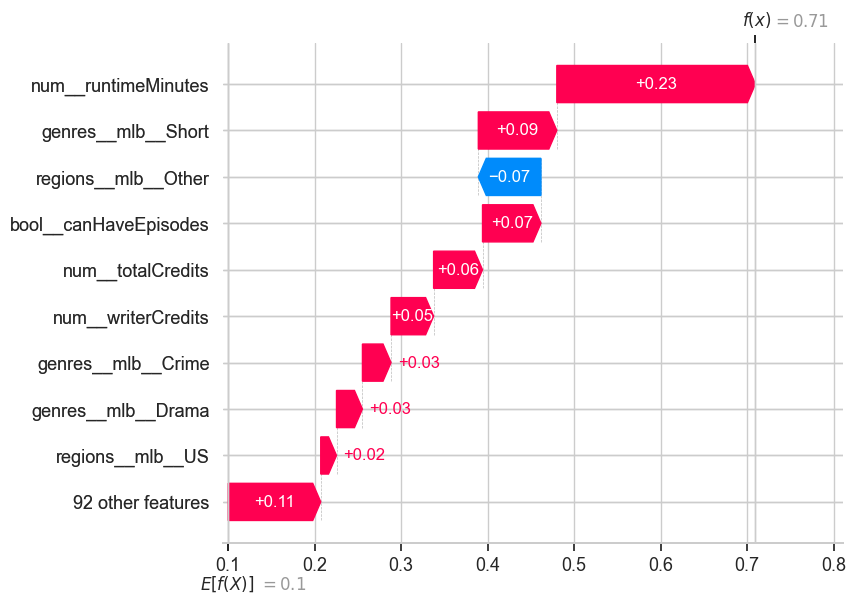


🎬 MEDOID 1 ANALYSIS
--------------------------------------------------
Predicted: tvMovie (50.9% confidence)
Ground Truth: video
❌ Prediction: INCORRECT
   Ground truth 'video' was ranked #3 with 10.4% probability
📊 Content characteristics:
   • Title: Wrestling Superheroes
   • Year: 1990
   • Runtime: 4.110873864173311
   • Rating: 6.1/10
   • Votes: 2.772588722239781
   • Genres: Sport
   • Regions: US
🔝 Top 3 predictions:
   1. 🎯 tvMovie: 50.9%
   2.    movie: 23.3%
   3. 🏷️ video: 10.4%


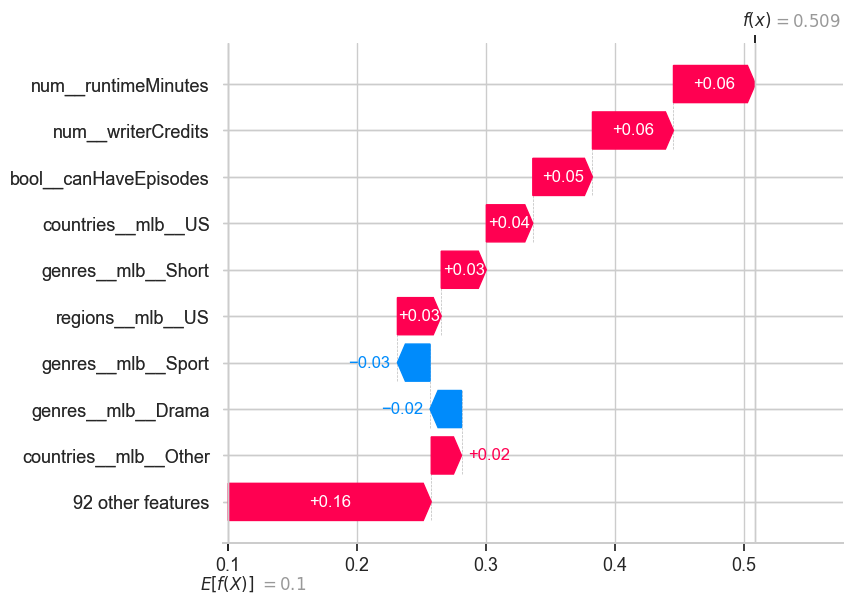


🎬 MEDOID 2 ANALYSIS
--------------------------------------------------
Predicted: movie (85.1% confidence)
Ground Truth: movie
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: Jui nam chai
   • Year: 1993
   • Runtime: 4.584967478670572
   • Rating: 6.4/10
   • Votes: 5.786897381366708
   • Genres: Comedy, Romance
   • Regions: GB, HK, US...
🔝 Top 3 predictions:
   1. 🎯 movie: 85.1%
   2.    tvMovie: 10.4%
   3.    video: 3.0%


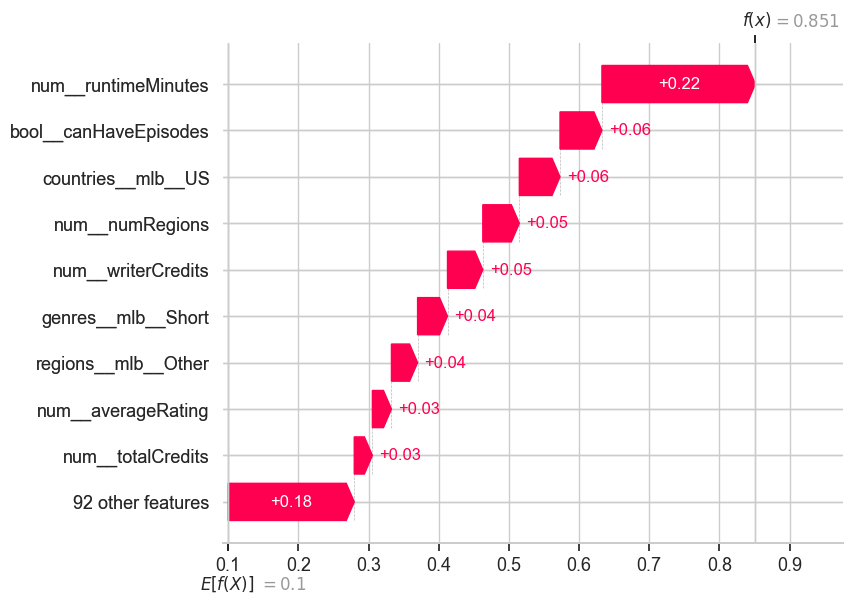


🎬 MEDOID 3 ANALYSIS
--------------------------------------------------
Predicted: movie (83.3% confidence)
Ground Truth: tvMovie
❌ Prediction: INCORRECT
   Ground truth 'tvMovie' was ranked #2 with 11.4% probability
📊 Content characteristics:
   • Title: Der Hammermörder
   • Year: 1990
   • Runtime: 4.51085950651685
   • Rating: 7.4/10
   • Votes: 4.672828834461906
   • Genres: Crime, Thriller
   • Regions: DE, FI
🔝 Top 3 predictions:
   1. 🎯 movie: 83.3%
   2. 🏷️ tvMovie: 11.4%
   3.    video: 3.7%


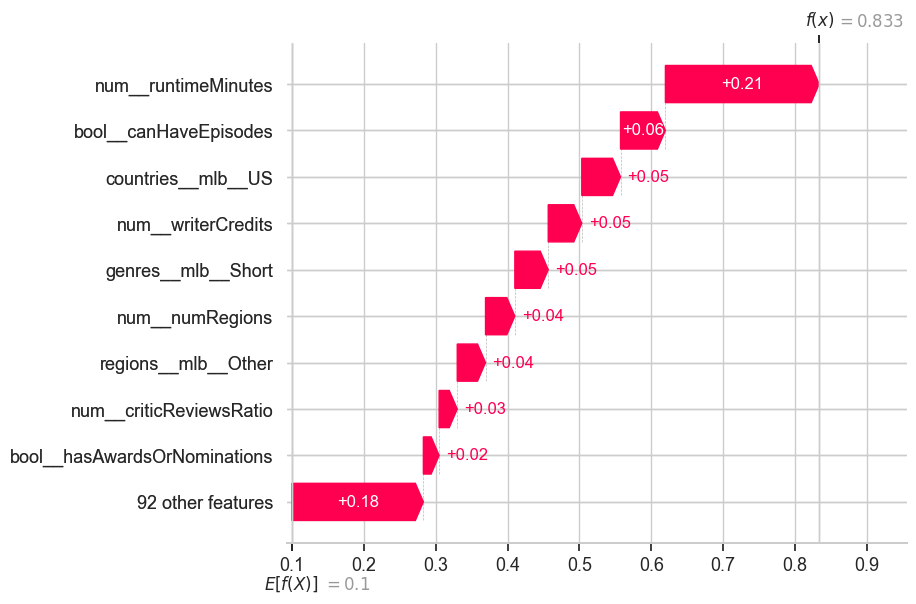


🎬 MEDOID 4 ANALYSIS
--------------------------------------------------
Predicted: movie (82.1% confidence)
Ground Truth: movie
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: Versiya polkovnika Zorina
   • Year: 1979
   • Runtime: 4.499809670330265
   • Rating: 6.8/10
   • Votes: 4.691347882229144
   • Genres: Crime, Mystery
   • Regions: RU, SUHH, DDDE...
🔝 Top 3 predictions:
   1. 🎯 movie: 82.1%
   2.    tvMovie: 14.6%
   3.    tvEpisode: 2.7%


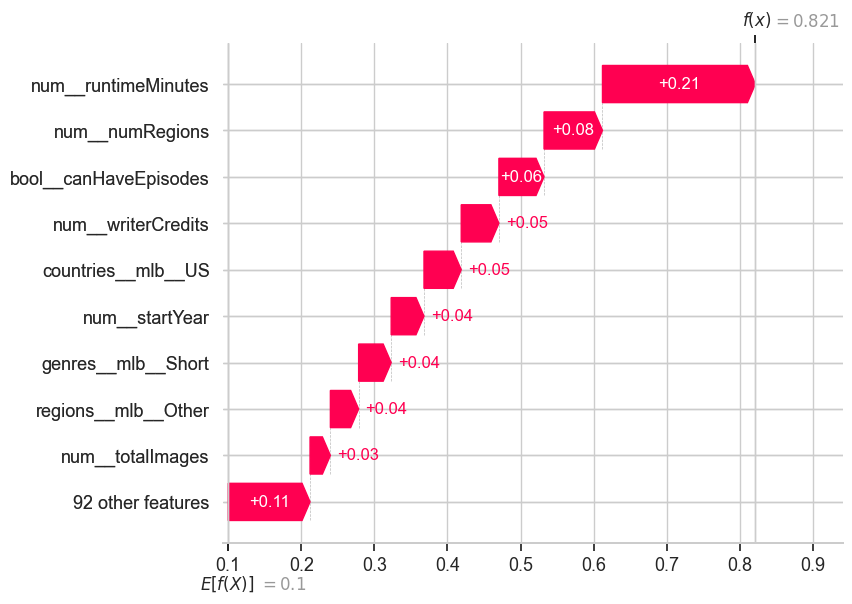


🎬 MEDOID 5 ANALYSIS
--------------------------------------------------
Predicted: tvEpisode (100.0% confidence)
Ground Truth: tvEpisode
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: Live Punishment 100th Episode
   • Year: 2017
   • Runtime: 3.4339872044851463
   • Rating: 8.1/10
   • Votes: 2.4849066497880004
   • Genres: Comedy, Reality-TV
🔝 Top 3 predictions:
   1. 🎯 tvEpisode: 100.0%
   2.    videoGame: 0.0%
   3.    video: 0.0%


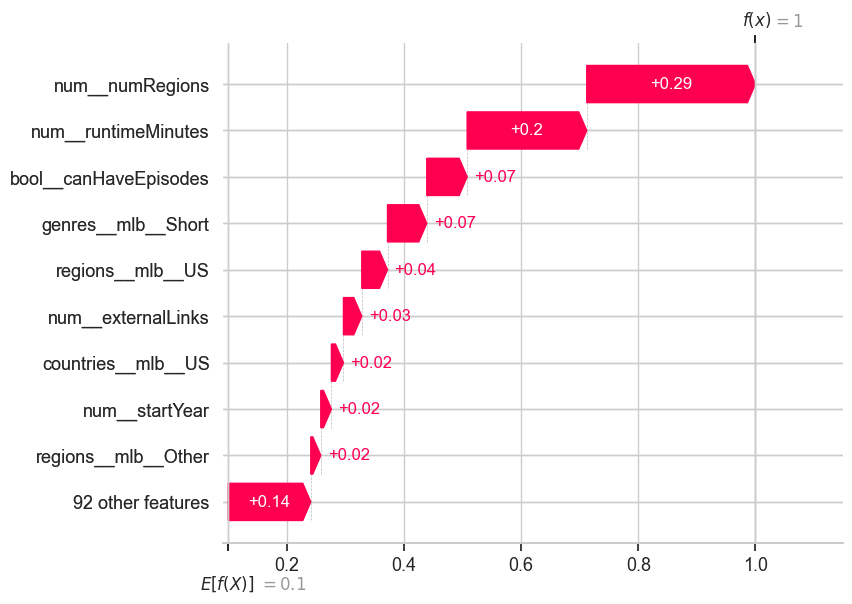


🎬 MEDOID 6 ANALYSIS
--------------------------------------------------
Predicted: tvEpisode (69.8% confidence)
Ground Truth: tvEpisode
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: To Dream of Wolves: Part 2
   • Year: 1988
   • Runtime: 3.4339872044851463
   • Rating: 7.6/10
   • Votes: 3.49650756146648
   • Genres: Horror, Thriller
   • Regions: US
🔝 Top 3 predictions:
   1. 🎯 tvEpisode: 69.8%
   2.    tvMovie: 12.6%
   3.    short: 5.6%


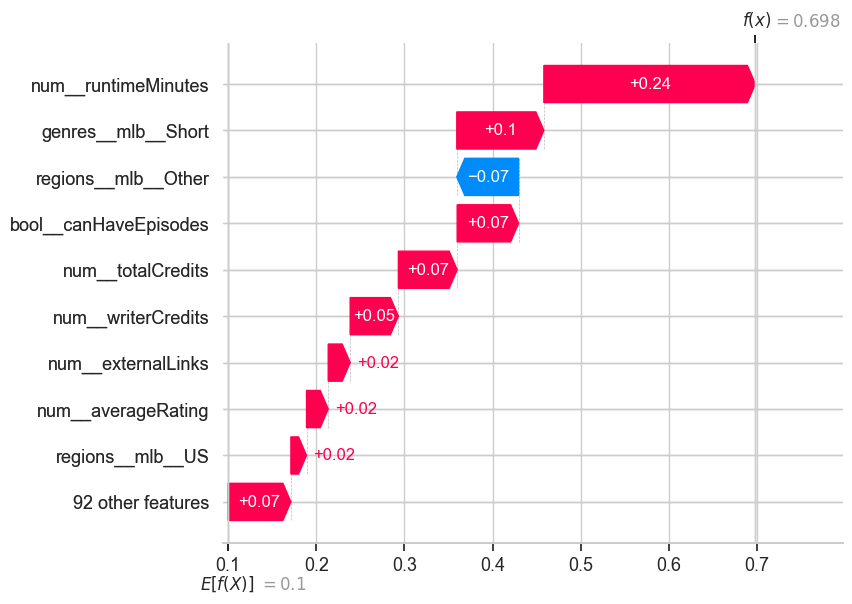


🎬 MEDOID 7 ANALYSIS
--------------------------------------------------
Predicted: movie (83.6% confidence)
Ground Truth: movie
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: The Lightship
   • Year: 1985
   • Runtime: 4.499809670330265
   • Rating: 6.3/10
   • Votes: 6.993932975223189
   • Genres: Crime, Drama, Thriller
   • Regions: DK, US, IT...
🔝 Top 3 predictions:
   1. 🎯 movie: 83.6%
   2.    tvMovie: 11.6%
   3.    video: 1.5%


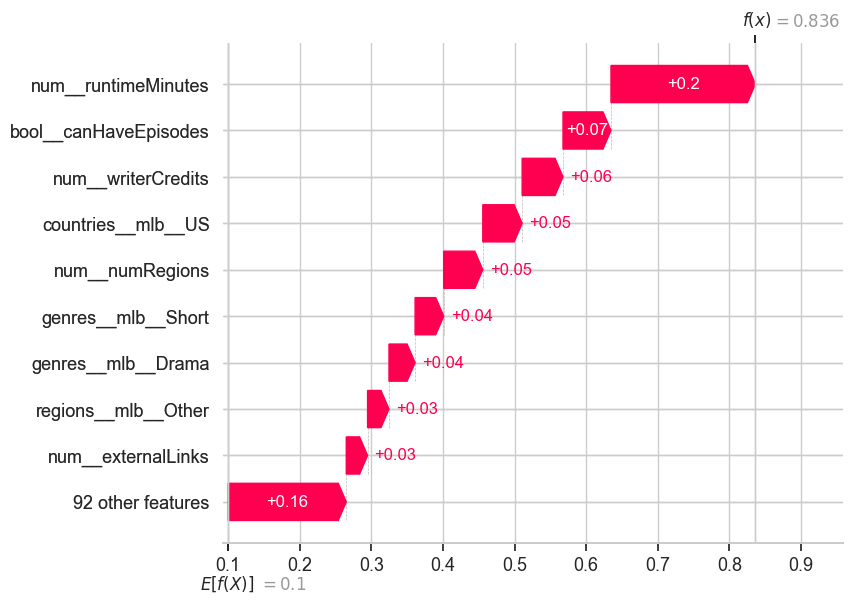


🎬 MEDOID 8 ANALYSIS
--------------------------------------------------
Predicted: short (97.7% confidence)
Ground Truth: short
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: Sekt
   • Year: 2020
   • Runtime: 3.4339872044851463
   • Rating: 7.4/10
   • Votes: 2.3978952727983707
   • Genres: Drama, Short
   • Regions: CA, GB, US...
🔝 Top 3 predictions:
   1. 🎯 short: 97.7%
   2.    tvEpisode: 0.9%
   3.    tvMovie: 0.8%


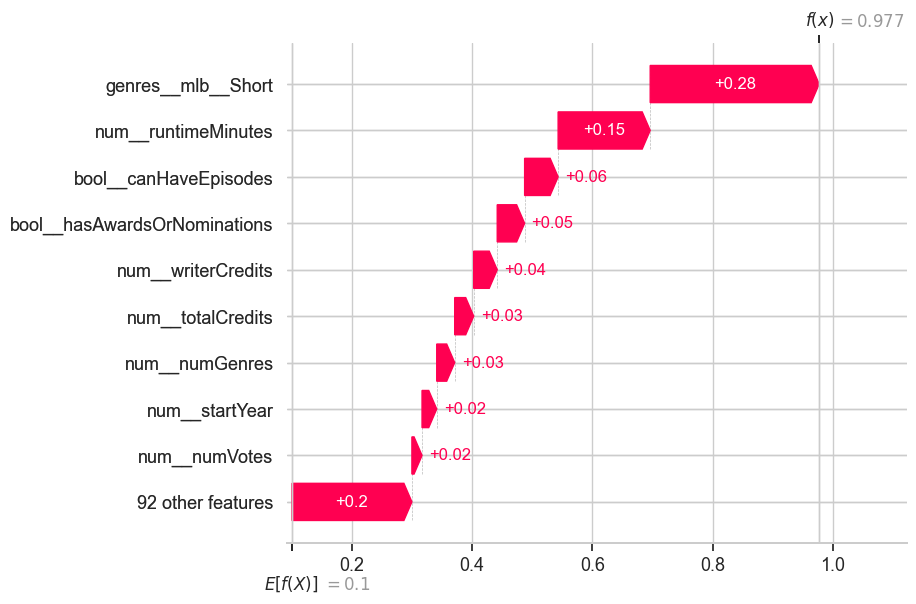


🎬 MEDOID 9 ANALYSIS
--------------------------------------------------
Predicted: short (87.3% confidence)
Ground Truth: short
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: Viola Chinesa
   • Year: 1977
   • Runtime: 2.19722457733622
   • Rating: 6.4/10
   • Votes: 3.784189633918261
   • Genres: Documentary, Short
   • Regions: BR
🔝 Top 3 predictions:
   1. 🎯 short: 87.3%
   2.    tvShort: 9.1%
   3.    video: 2.8%


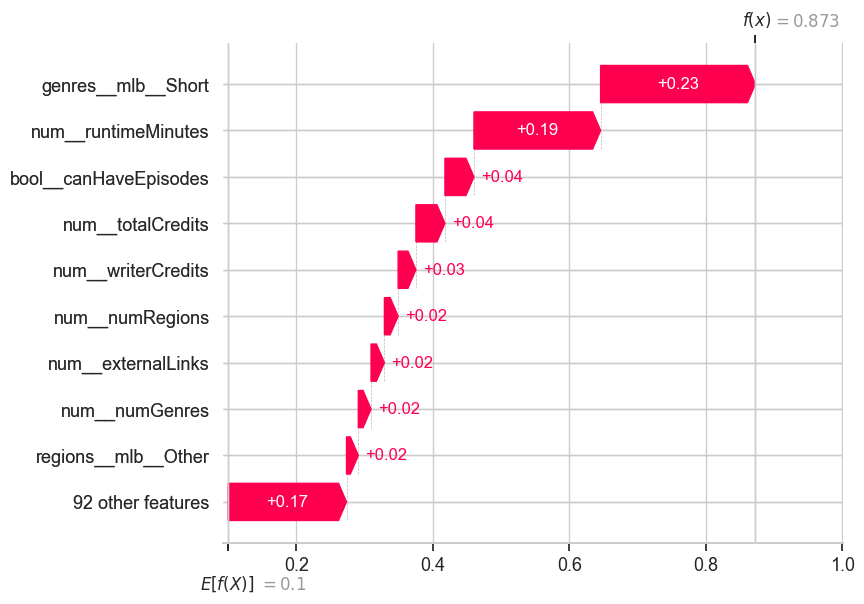


🎬 MEDOID 10 ANALYSIS
--------------------------------------------------
Predicted: tvEpisode (58.7% confidence)
Ground Truth: tvEpisode
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: Credible Witness
   • Year: 1993
   • Runtime: 3.258096538021482
   • Rating: 8.0/10
   • Votes: 3.784189633918261
   • Genres: Crime, Drama
   • Regions: GB
🔝 Top 3 predictions:
   1. 🎯 tvEpisode: 58.7%
   2.    tvMovie: 16.5%
   3.    short: 12.0%


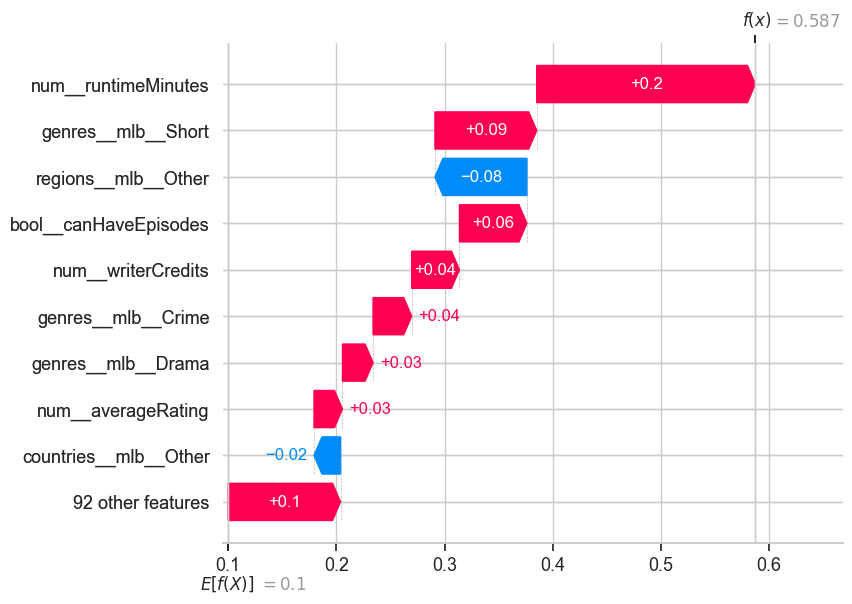


🎬 MEDOID 11 ANALYSIS
--------------------------------------------------
Predicted: movie (95.2% confidence)
Ground Truth: tvMovie
❌ Prediction: INCORRECT
   Ground truth 'tvMovie' was ranked #2 with 3.5% probability
📊 Content characteristics:
   • Title: Love Songs
   • Year: 1999
   • Runtime: 4.624972813284271
   • Rating: 6.4/10
   • Votes: 5.429345628954441
   • Genres: Drama, Romance
   • Regions: US, HU
🔝 Top 3 predictions:
   1. 🎯 movie: 95.2%
   2. 🏷️ tvMovie: 3.5%
   3.    video: 0.6%


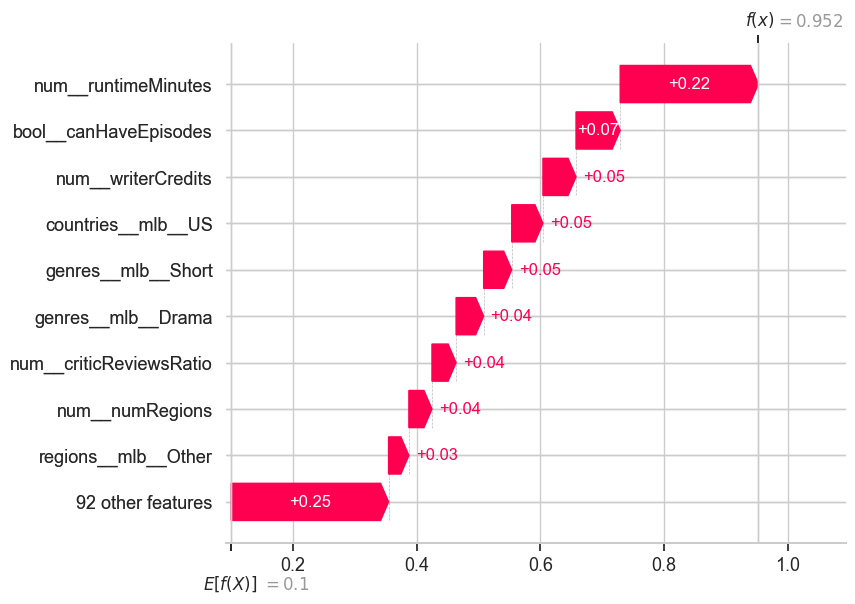


🎬 MEDOID 12 ANALYSIS
--------------------------------------------------
Predicted: movie (81.4% confidence)
Ground Truth: movie
✅ Prediction: CORRECT
📊 Content characteristics:
   • Title: That Was Then... This Is Now
   • Year: 1985
   • Runtime: 4.634728988229636
   • Rating: 6.1/10
   • Votes: 7.916807490937603
   • Genres: Crime, Drama
   • Regions: PL, IT, FR...
🔝 Top 3 predictions:
   1. 🎯 movie: 81.4%
   2.    tvMovie: 13.8%
   3.    video: 2.1%


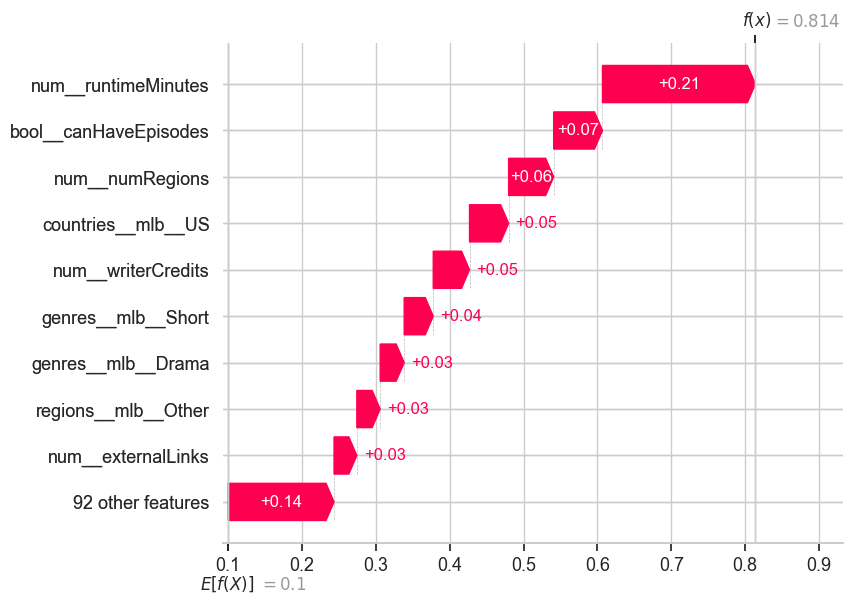

In [ ]:
# Analyze all medoids with detailed output including ground truth and interpretable features
for medoid_idx in range(len(medoid_indices)):
    print(f"\n🎬 MEDOID {medoid_idx} ANALYSIS")
    print("-" * 50)
    
    # Get prediction data
    original_data_idx = medoid_info[medoid_idx]['index']
    medoid_original_data = df_test.iloc[original_data_idx:original_data_idx+1]
    medoid_prediction = rf_pipeline.predict(medoid_original_data)[0]
    medoid_proba = rf_pipeline.predict_proba(medoid_original_data)[0]
    predicted_class_idx = np.argmax(medoid_proba)
    predicted_class_name = rf_pipeline.classes_[predicted_class_idx]
    
    # Get ground truth
    ground_truth = y_test_titleType.iloc[original_data_idx]
    
    # Check if prediction is correct
    is_correct = medoid_prediction == ground_truth
    status_emoji = "✅" if is_correct else "❌"
    
    # Display results
    print(f"Predicted: {predicted_class_name} ({medoid_proba[predicted_class_idx]:.1%} confidence)")
    print(f"Ground Truth: {ground_truth}")
    print(f"{status_emoji} Prediction: {'CORRECT' if is_correct else 'INCORRECT'}")
    
    if not is_correct:
        # Show where the ground truth ranked in the predictions
        ground_truth_idx = np.where(rf_pipeline.classes_ == ground_truth)[0][0]
        ground_truth_prob = medoid_proba[ground_truth_idx]
        prob_rank = np.sum(medoid_proba > ground_truth_prob) + 1
        print(f"   Ground truth '{ground_truth}' was ranked #{prob_rank} with {ground_truth_prob:.1%} probability")
    
    # Enhanced content characteristics with more interpretable formatting
    print(f"📊 Content characteristics:")
    sample = medoid_original_data.iloc[0]
    
    # Basic info
    print(f"   • Title: {sample.get('originalTitle', 'N/A')}")
    print(f"   • Year: {sample.get('startYear', 'N/A')}")
    
    # Runtime with better formatting
    runtime = sample.get('runtimeMinutes', 'N/A')
    print(f"   • Runtime: {runtime}")
    
    # Rating with interpretation
    rating = sample.get('averageRating', 'N/A')
    if pd.notna(rating) and rating != 'N/A':
        print(f"   • Rating: {rating}/10")
    else:
        print(f"   • Rating: N/A")
    
    # Votes with better formatting
    votes = sample.get('numVotes', 'N/A')
    if pd.notna(votes) and votes != 'N/A':
        print(f"   • Votes: {votes:,}")
    else:
        print(f"   • Votes: N/A")
    
    # Show genres if available
    try:
        if 'genres' in sample.index:
            genres = sample['genres']
            if genres is not None and not (isinstance(genres, float) and pd.isna(genres)):
                if isinstance(genres, str):
                    try:
                        genres = ast.literal_eval(genres)
                    except:
                        pass
                if isinstance(genres, list) and len(genres) > 0:
                    print(f"   • Genres: {', '.join(genres[:3])}{'...' if len(genres) > 3 else ''}")
    except:
        pass
    
    # Show regions if available - fixed version
    try:
        if 'regions' in sample.index:
            regions = sample['regions']
            if regions is not None and not (isinstance(regions, float) and pd.isna(regions)):
                if isinstance(regions, str):
                    try:
                        regions = ast.literal_eval(regions)
                    except:
                        pass
                if isinstance(regions, list) and len(regions) > 0:
                    print(f"   • Regions: {', '.join(regions[:3])}{'...' if len(regions) > 3 else ''}")
    except:
        pass
    
    # Show top 3 predictions for context
    print(f"Top 3 predictions:")
    top_3_indices = np.argsort(medoid_proba)[-3:][::-1]
    for i, idx in enumerate(top_3_indices):
        class_name = rf_pipeline.classes_[idx]
        prob = medoid_proba[idx]
        marker = "🎯" if class_name == predicted_class_name else "🏷️" if class_name == ground_truth else "  "
        print(f"   {i+1}. {marker} {class_name}: {prob:.1%}")
    
    # Create waterfall plot
    plt.figure(figsize=(14, 8))
    shap.plots._waterfall.waterfall_legacy(
        shap_explainer.expected_value[predicted_class_idx],
        shap_vals[medoid_idx][:, predicted_class_idx],
        feature_names=feature_names, 
        max_display=10
    )

    print("=" * 50)


 MISCLASSIFIED MEDOID 1 ANALYSIS (Ground Truth Focus)
❌ Model predicted: tvMovie (50.9% confidence)
🏷️  Ground truth: video (10.4% probability)
Ground truth ranked #3 out of 10 classes

Content characteristics:
   • Title: Wrestling Superheroes
   • Year: 1990
   • Runtime: 4.110873864173311 min
   • Rating: 6.1/10
   • Votes: 2.772588722239781
   • Genres: Sport

 Top 5 predictions:
   1. 🎯 PREDICTED tvMovie: 50.9%
   2.    movie: 23.3%
   3. 🏷️  TRUE video: 10.4%
   4.    tvSpecial: 6.3%
   5.    tvEpisode: 3.7%


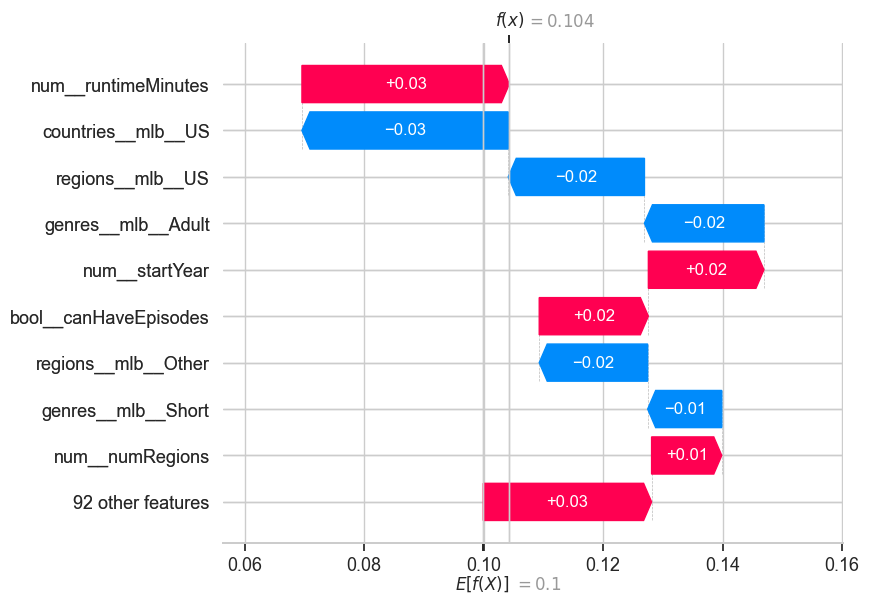



 MISCLASSIFIED MEDOID 3 ANALYSIS (Ground Truth Focus)
❌ Model predicted: movie (83.3% confidence)
🏷️  Ground truth: tvMovie (11.4% probability)
Ground truth ranked #2 out of 10 classes

Content characteristics:
   • Title: Der Hammermörder
   • Year: 1990
   • Runtime: 4.51085950651685 min
   • Rating: 7.4/10
   • Votes: 4.672828834461906
   • Genres: Crime, Thriller

 Top 5 predictions:
   1. 🎯 PREDICTED movie: 83.3%
   2. 🏷️  TRUE tvMovie: 11.4%
   3.    video: 3.7%
   4.    tvEpisode: 0.7%
   5.    tvSpecial: 0.4%


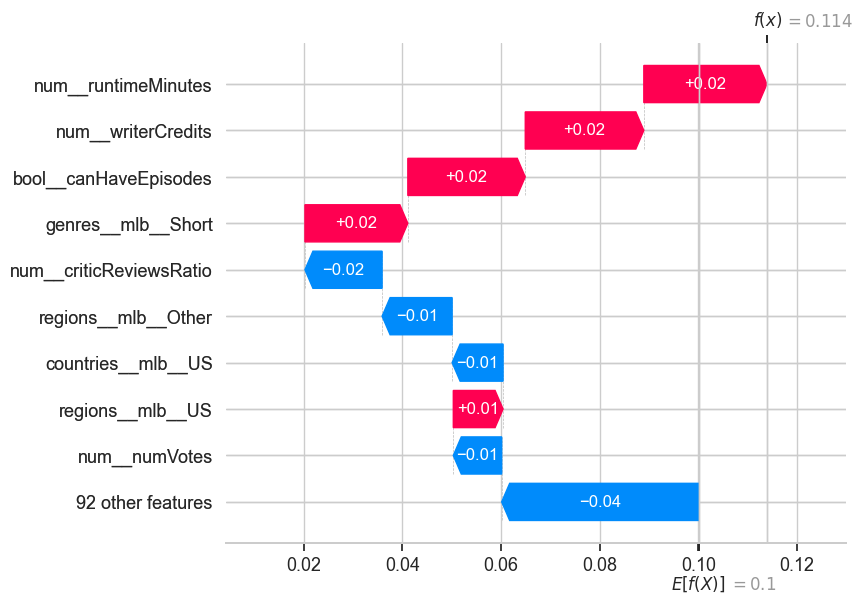



 MISCLASSIFIED MEDOID 11 ANALYSIS (Ground Truth Focus)
❌ Model predicted: movie (95.2% confidence)
🏷️  Ground truth: tvMovie (3.5% probability)
Ground truth ranked #2 out of 10 classes

Content characteristics:
   • Title: Love Songs
   • Year: 1999
   • Runtime: 4.624972813284271 min
   • Rating: 6.4/10
   • Votes: 5.429345628954441
   • Genres: Drama, Romance

 Top 5 predictions:
   1. 🎯 PREDICTED movie: 95.2%
   2. 🏷️  TRUE tvMovie: 3.5%
   3.    video: 0.6%
   4.    tvEpisode: 0.4%
   5.    tvSpecial: 0.3%


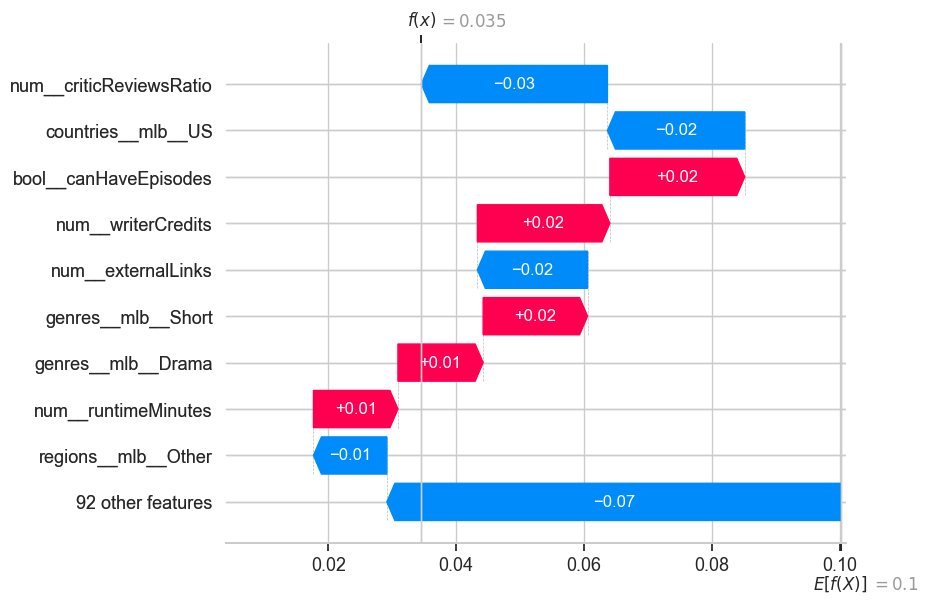

In [88]:
# Analyze misclassified medoids 1, 3 and 11 - waterfall plots for ground truth classes
misclassified_medoids = [1, 3, 11]

for medoid_idx in misclassified_medoids:
    print(f"\n MISCLASSIFIED MEDOID {medoid_idx} ANALYSIS (Ground Truth Focus)")
    print("=" * 60)
    
    # Get prediction data
    original_data_idx = medoid_info[medoid_idx]['index']
    medoid_original_data = df_test.iloc[original_data_idx:original_data_idx+1]
    medoid_prediction = rf_pipeline.predict(medoid_original_data)[0]
    medoid_proba = rf_pipeline.predict_proba(medoid_original_data)[0]
    
    # Get ground truth and indices
    ground_truth = y_test_titleType.iloc[original_data_idx]
    predicted_class_idx = np.argmax(medoid_proba)
    predicted_class_name = rf_pipeline.classes_[predicted_class_idx]
    ground_truth_idx = np.where(rf_pipeline.classes_ == ground_truth)[0][0]
    
    # Display results
    print(f"❌ Model predicted: {predicted_class_name} ({medoid_proba[predicted_class_idx]:.1%} confidence)")
    print(f"🏷️  Ground truth: {ground_truth} ({medoid_proba[ground_truth_idx]:.1%} probability)")
    
    # Show ranking of ground truth
    prob_rank = np.sum(medoid_proba > medoid_proba[ground_truth_idx]) + 1
    print(f"Ground truth ranked #{prob_rank} out of {len(rf_pipeline.classes_)} classes")
    
    # Enhanced content characteristics
    print(f"\nContent characteristics:")
    sample = medoid_original_data.iloc[0]
    print(f"   • Title: {sample.get('originalTitle', 'N/A')}")
    print(f"   • Year: {sample.get('startYear', 'N/A')}")
    
    # Runtime with better formatting
    runtime = sample.get('runtimeMinutes', 'N/A')
    if pd.notna(runtime) and runtime != 'N/A':
        print(f"   • Runtime: {runtime} min")
    else:
        print(f"   • Runtime: N/A")
    
    # Rating with interpretation
    rating = sample.get('averageRating', 'N/A')
    if pd.notna(rating) and rating != 'N/A':
        print(f"   • Rating: {rating}/10")
    else:
        print(f"   • Rating: N/A")
    
    # Votes with better formatting
    votes = sample.get('numVotes', 'N/A')
    if pd.notna(votes) and votes != 'N/A':
        print(f"   • Votes: {votes:,}")
    else:
        print(f"   • Votes: N/A")
    
    # Show genres and regions if available
    try:
        if 'genres' in sample.index:
            genres = sample['genres']
            if genres is not None and not (isinstance(genres, float) and pd.isna(genres)):
                if isinstance(genres, str):
                    try:
                        genres = ast.literal_eval(genres)
                    except:
                        pass
                if isinstance(genres, list) and len(genres) > 0:
                    print(f"   • Genres: {', '.join(genres[:3])}{'...' if len(genres) > 3 else ''}")
    except:
        pass
    
    # Show top 5 predictions for context
    print(f"\n Top 5 predictions:")
    top_5_indices = np.argsort(medoid_proba)[-5:][::-1]
    for i, idx in enumerate(top_5_indices):
        class_name = rf_pipeline.classes_[idx]
        prob = medoid_proba[idx]
        if class_name == predicted_class_name:
            marker = "🎯 PREDICTED"
        elif class_name == ground_truth:
            marker = "🏷️  TRUE"
        else:
            marker = "  "
        print(f"   {i+1}. {marker} {class_name}: {prob:.1%}")
    
    # Create waterfall plot for the GROUND TRUTH class
    plt.figure(figsize=(16, 10))
    shap.plots._waterfall.waterfall_legacy(
        shap_explainer.expected_value[ground_truth_idx],
        shap_vals[medoid_idx][:, ground_truth_idx],
        feature_names=feature_names, 
        max_display=10
    )

    
    print("\n" + "=" * 60)

# Comments

12 out of 13 datapoints belong/were classified as the top 3 titleTypes: movie, tvEpisode and short. + 1 medoid belonged to video and was classified as tvMovie.

- runtimeMinutes was the most important feature for almost all records, as anticipated by the Random Forest feature importance
- tvEpisode: n. 5 was 100% confident → the biggest contributor was numRegions (+0.29), followed by runtimeMinutes (+0.2), canHaveEpisode and genre Short. For the other tvEpisode medoids, we don't find numRegions; moreover, they have small negative contributions from regions_Other: the model has learnt a connection between tvEpisodes and missing values for regions. Sign of overfitting.
- N. 8 and 9 are shorts: both have as most important feat genre Short (+0.28 and +0.23, respectively), followed by runtimeMinutes (+0.15 and +0.19). All positive feature contributions.
- movie (correctly classified): all classified w/ > 80% probability, the two most important features are runtimeMinutes (between 0.2 and 0.29) and canHaveEpisodes.


Misclassified instances:
- n. 1: tvMovie (50.9%) instead of video (10.4%)
- n. 3: movie (83%) instead of tvMovie (11.4%)
- n. 11: movie (95.2%) instead of tvMovie (3.5%)

N.1: not too confident. Mostly a sum of small positive contributions, the biggest are runtimeMinutes and num of writersCredits (both +0.06). Small negative contributions: -0.03 genre Sport, -0.02 genre Drama.
VS its waterfall plot for video: still small positive contribution for runtimeMinutes (+0.03), negative contributions for the fact that it was produced and distributed in the US, that it isn't tagged as genre Short (it's 1h long) and it is tagged as genre Adult.

movies instead of tvMovie: quite confident, values similar to the other movies. Waterfall plot for the real class: lots of small negative contributions that added up, including criticReviewsRatio.




Medoid information:
Cluster 0: Index 20235 (original row 20235), Distance to centroid: 0.8444
Cluster 1: Index 22055 (original row 22055), Distance to centroid: 0.5422
Cluster 2: Index 14823 (original row 14823), Distance to centroid: 1.1324
Cluster 3: Index 1510 (original row 1510), Distance to centroid: 0.9395
Cluster 4: Index 27942 (original row 27942), Distance to centroid: 0.8320
Cluster 5: Index 36160 (original row 36160), Distance to centroid: 0.7137
Cluster 6: Index 31905 (original row 31905), Distance to centroid: 0.6887
Cluster 7: Index 22035 (original row 22035), Distance to centroid: 0.7008
Cluster 8: Index 38986 (original row 38986), Distance to centroid: 0.7051
Cluster 9: Index 35444 (original row 35444), Distance to centroid: 0.5784
Cluster 10: Index 24486 (original row 24486), Distance to centroid: 0.5986
Cluster 11: Index 37267 (original row 37267), Distance to centroid: 1.1592
Cluster 12: Index 4664 (original row 4664), Distance to centroid: 0.9085

In [90]:
df_test.iloc[medoid_info[5]['index']]

originalTitle             Live Punishment 100th Episode
startYear                                          2017
runtimeMinutes                                 3.433987
numVotes                                       2.484907
totalImages                                    0.693147
totalCredits                                    2.70805
canHaveEpisodes                                   False
numRegions                                          0.0
countryOfOrigin                                      []
genres                             [Comedy, Reality-TV]
companiesNumber                                0.693147
averageRating                                       8.1
regions                                              []
externalLinks                                       0.0
writerCredits                                  0.693147
numGenres                                             2
criticReviewsRatio                                  0.0
hasAwards                                       